In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split and CV
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("heart.csv")

print("Dataset loaded successfully!\n")

print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!

Dataset shape:
(918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# ==========================================
# DATASET INFO
# ==========================================

print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
# ==========================================
# FEATURES AND TARGET
# ==========================================

TARGET_COLUMN = "HeartDisease"

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (918, 11)
Target shape: (918,)


In [ ]:
# ==========================================
# COLUMN TYPES
# ==========================================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Numerical columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


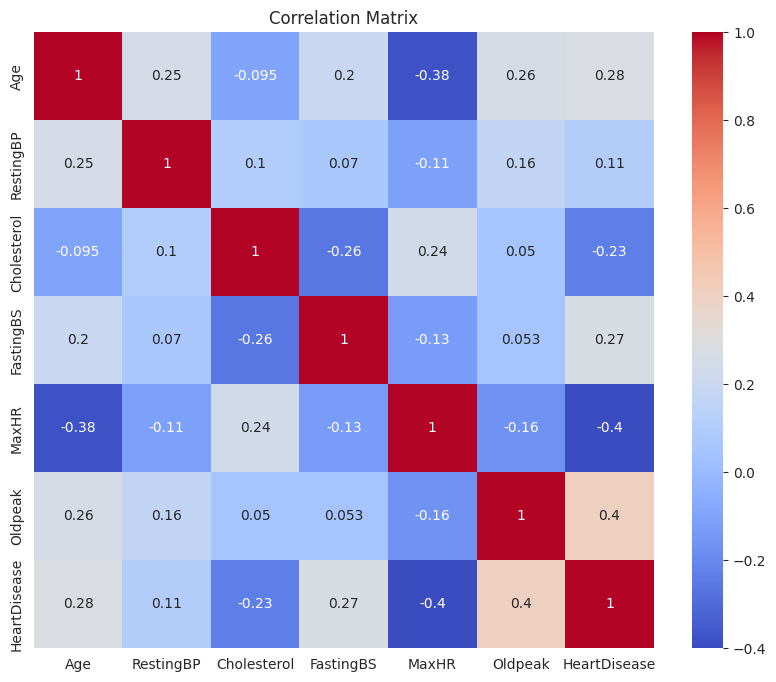

In [ ]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (734, 11)
Testing set: (184, 11)


In [ ]:
# ==========================================
# PREPROCESSING
# ==========================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# ==========================================
# MODEL EVALUATION FUNCTION
# ==========================================

def evaluate_model(model, X_test, y_test, model_name="Model"):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n========== {model_name} ==========")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{model_name} - ROC Curve")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

In [ ]:
# ==========================================
# FEATURE SELECTION WITH DECISION TREE
# ==========================================

# Pipeline
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

# Train model
dt_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
# ==========================================
# GET FEATURE NAMES
# ==========================================

# Get transformed feature names
encoded_cat_features = dt_pipeline.named_steps[
    'preprocessor'
].named_transformers_['cat'].named_steps[
    'onehot'
].get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([
    numerical_cols,
    encoded_cat_features
])

print("Total transformed features:", len(all_feature_names))

Total transformed features: 20


In [ ]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importances = dt_pipeline.named_steps['clf'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance_df.head(15))

,Feature,Importance
19,ST_Slope_Up,0.421219
4,MaxHR,0.123239
8,ChestPainType_ASY,0.087742
5,Oldpeak,0.078614
2,Cholesterol,0.074122
0,Age,0.065825
1,RestingBP,0.055960
3,FastingBS,0.019032
6,Sex_F,0.016010
7,Sex_M,0.015402


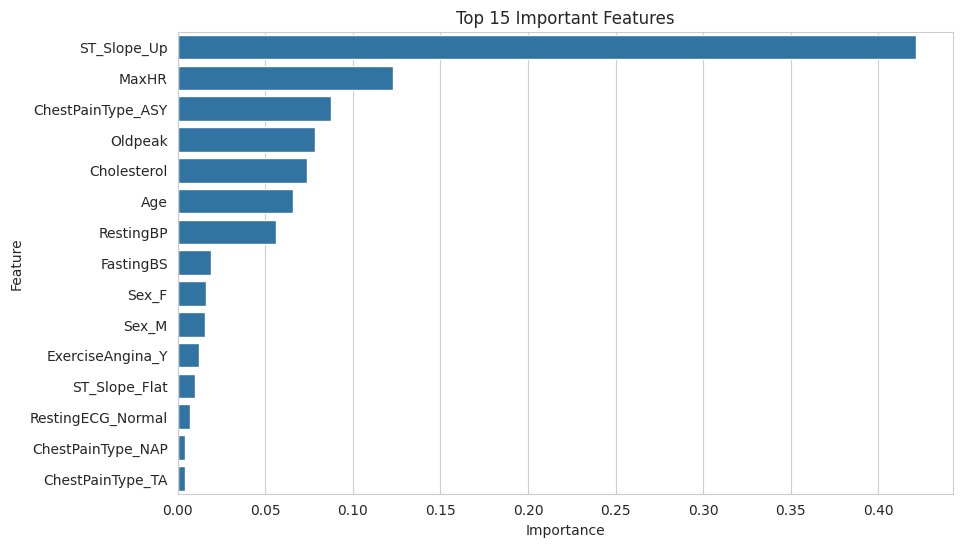

In [ ]:
# ==========================================
# FEATURE IMPORTANCE PLOT
# ==========================================

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# ==========================================
# MOST IMPORTANT FEATURES
# ==========================================

print("Top 10 Most Important Features:\n")

for idx, row in feature_importance_df.head(10).iterrows():
    print(f"{row['Feature']} --> {row['Importance']:.4f}")

Top 10 Most Important Features:

ST_Slope_Up --> 0.4212
MaxHR --> 0.1232
ChestPainType_ASY --> 0.0877
Oldpeak --> 0.0786
Cholesterol --> 0.0741
Age --> 0.0658
RestingBP --> 0.0560
FastingBS --> 0.0190
Sex_F --> 0.0160
Sex_M --> 0.0154


In [ ]:
# ==========================================
# CROSS-VALIDATION SETUP
# ==========================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

print("5-fold stratified cross-validation created.")

5-fold stratified cross-validation created.


In [ ]:
# ==========================================
# DECISION TREE - HYPERPARAMETER TUNING
# ==========================================

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': [None, 'sqrt', 'log2']
}

dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:")
print(dt_grid.best_params_)

print("\nBest CV F1 score:")
print(dt_grid.best_score_)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best parameters:
{'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__max_features': None, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10}

Best CV F1 score:
0.8484330904794929



========== Decision Tree ==========
Accuracy : 0.8261
Precision: 0.8646
Recall   : 0.8137
F1 Score : 0.8384
AUC Score: 0.8729

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        82
           1       0.86      0.81      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



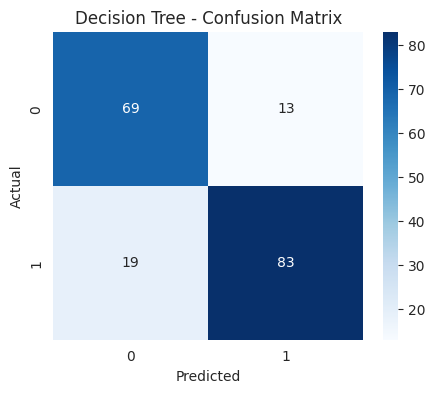

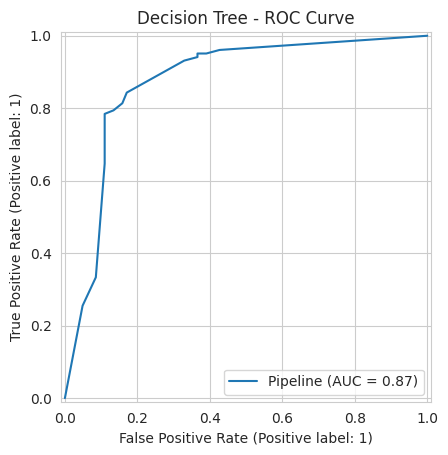

In [21]:
# ==========================================
# DECISION TREE - TEST EVALUATION
# ==========================================

best_dt = dt_grid.best_estimator_

dt_results = evaluate_model(
    best_dt,
    X_test,
    y_test,
    model_name="Decision Tree"
)

results.append(dt_results)

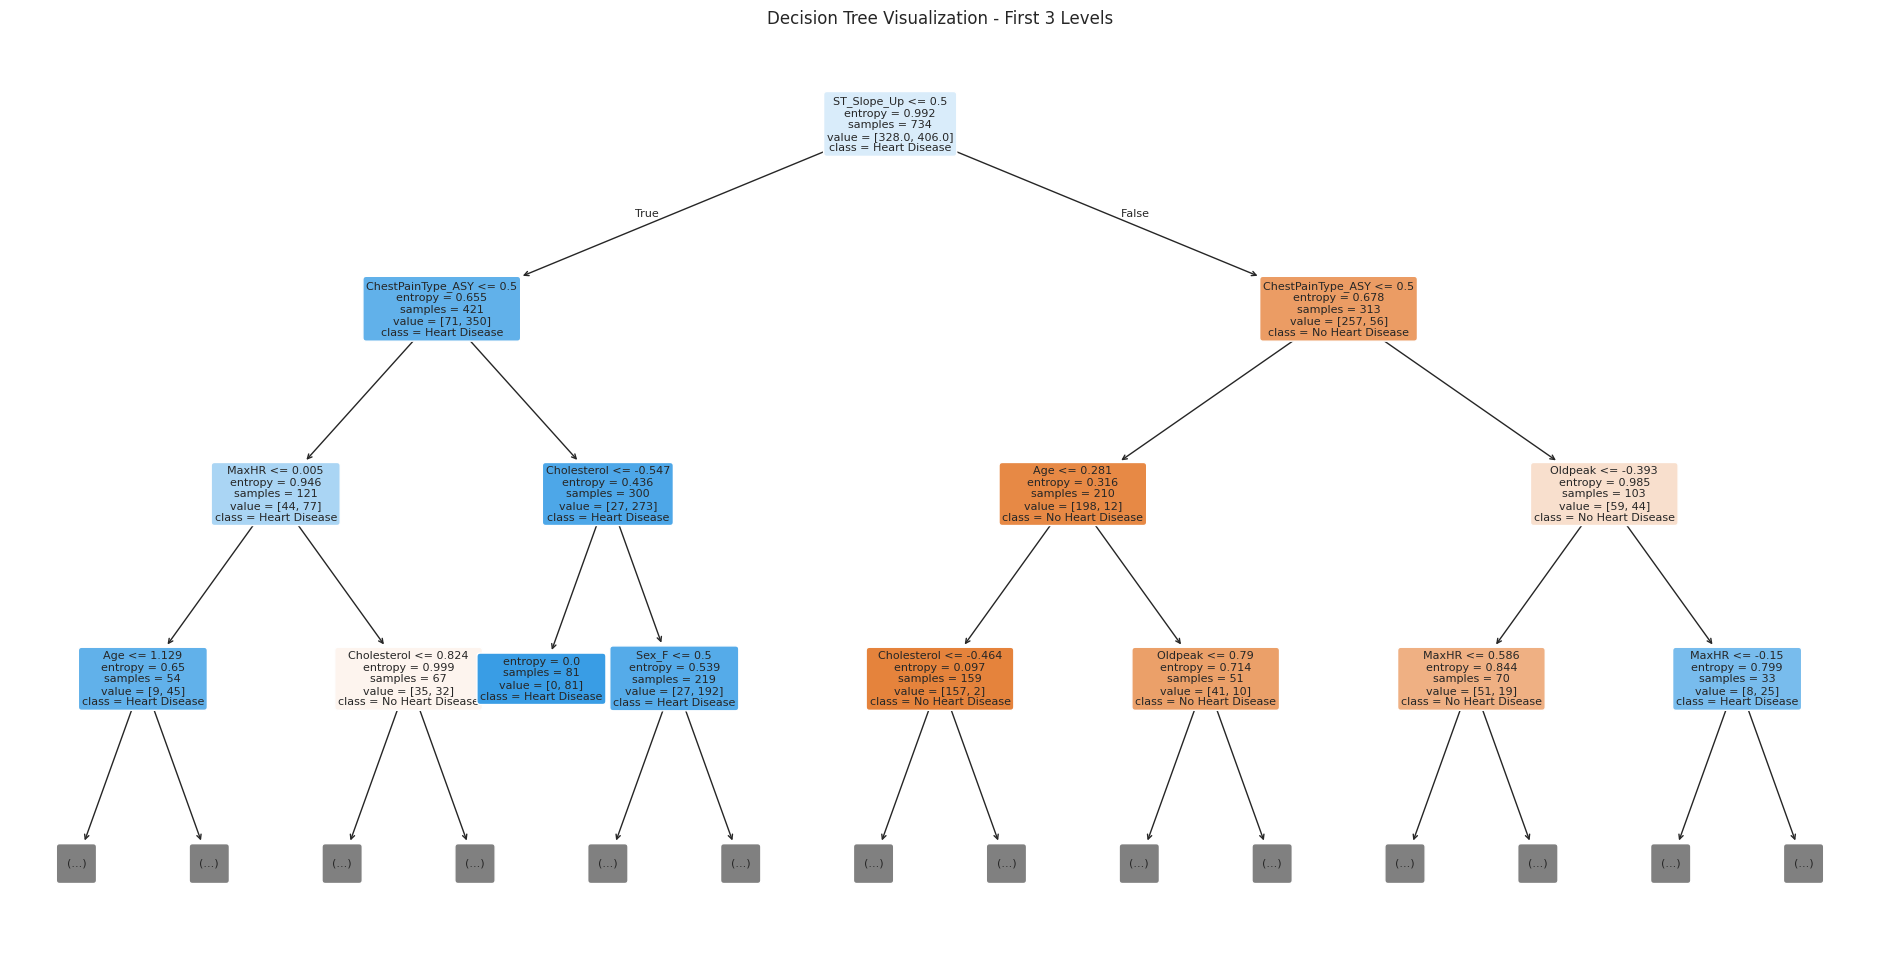

In [22]:
# ==========================================
# DECISION TREE VISUALIZATION
# ==========================================

from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    best_dt.named_steps['clf'],
    feature_names=all_feature_names,
    class_names=['No Heart Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization - First 3 Levels")
plt.show()

In [23]:
# ==========================================
# DECISION TREE INTERPRETATION
# ==========================================

print("Decision Tree Summary")
print("---------------------")
print("Best parameters:", dt_grid.best_params_)
print(f"Best cross-validation F1 score: {dt_grid.best_score_:.4f}")
print(f"Test F1 score: {dt_results['F1']:.4f}")
print(f"Test AUC score: {dt_results['AUC']:.4f}")

Decision Tree Summary
---------------------
Best parameters: {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__max_features': None, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10}
Best cross-validation F1 score: 0.8484
Test F1 score: 0.8384
Test AUC score: 0.8729


In [24]:
# ==========================================
# RANDOM FOREST - HYPERPARAMETER TUNING
# ==========================================

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', None]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest CV F1 score:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters:
{'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}

Best CV F1 score:
0.8843001661654186



========== Random Forest ==========
Accuracy : 0.9022
Precision: 0.8889
Recall   : 0.9412
F1 Score : 0.9143
AUC Score: 0.9302

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.89        82
           1       0.89      0.94      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



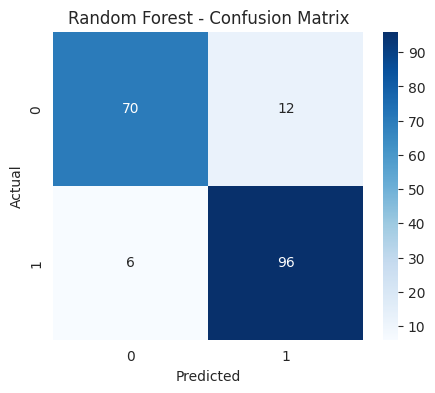

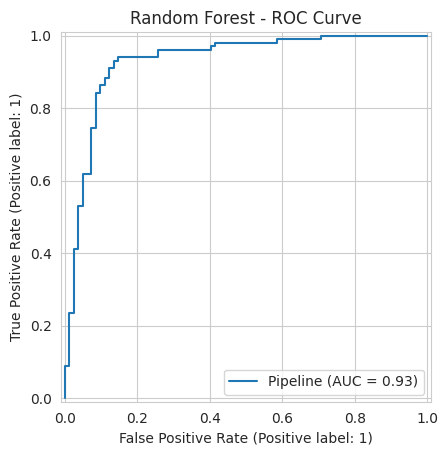

In [25]:
# ==========================================
# RANDOM FOREST - TEST EVALUATION
# ==========================================

best_rf = rf_grid.best_estimator_

rf_results = evaluate_model(
    best_rf,
    X_test,
    y_test,
    model_name="Random Forest"
)

results.append(rf_results)

In [26]:
# ==========================================
# RANDOM FOREST - FEATURE IMPORTANCE
# ==========================================

rf_importances = best_rf.named_steps['clf'].feature_importances_

rf_feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_importances
})

rf_feature_importance_df = rf_feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(rf_feature_importance_df.head(15))

,Feature,Importance
19,ST_Slope_Up,0.206013
18,ST_Slope_Flat,0.129021
8,ChestPainType_ASY,0.118690
5,Oldpeak,0.084859
15,ExerciseAngina_N,0.071012
2,Cholesterol,0.070693
16,ExerciseAngina_Y,0.067054
4,MaxHR,0.063952
0,Age,0.040210
1,RestingBP,0.034247


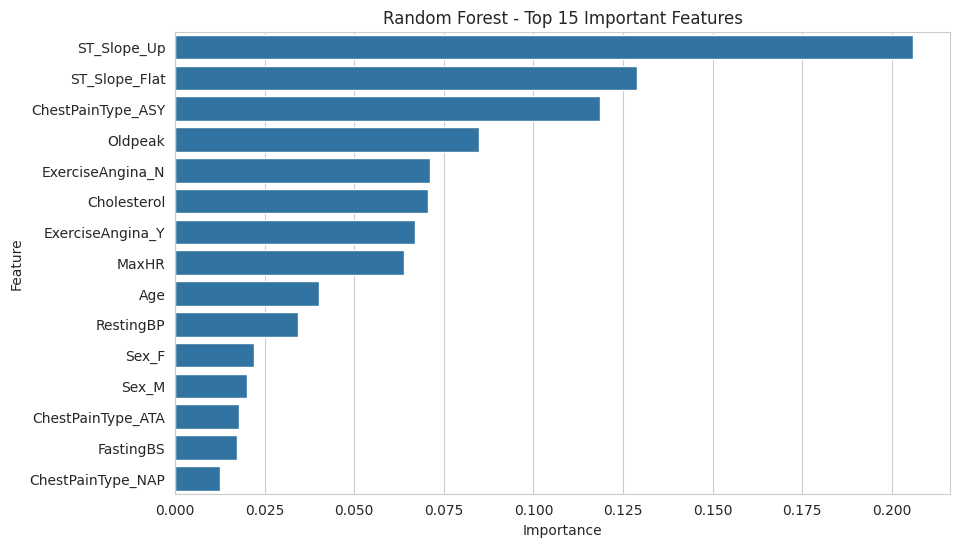

In [27]:
# ==========================================
# RANDOM FOREST - FEATURE IMPORTANCE PLOT
# ==========================================

top_rf_features = rf_feature_importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rf_features,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest - Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [28]:
# ==========================================
# RANDOM FOREST INTERPRETATION
# ==========================================

print("Random Forest Summary")
print("---------------------")
print("Best parameters:", rf_grid.best_params_)
print(f"Best cross-validation F1 score: {rf_grid.best_score_:.4f}")
print(f"Test F1 score: {rf_results['F1']:.4f}")
print(f"Test AUC score: {rf_results['AUC']:.4f}")

print("\nTop 10 important features:")
for idx, row in rf_feature_importance_df.head(10).iterrows():
    print(f"{row['Feature']} --> {row['Importance']:.4f}")

Random Forest Summary
---------------------
Best parameters: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best cross-validation F1 score: 0.8843
Test F1 score: 0.9143
Test AUC score: 0.9302

Top 10 important features:
ST_Slope_Up --> 0.2060
ST_Slope_Flat --> 0.1290
ChestPainType_ASY --> 0.1187
Oldpeak --> 0.0849
ExerciseAngina_N --> 0.0710
Cholesterol --> 0.0707
ExerciseAngina_Y --> 0.0671
MaxHR --> 0.0640
Age --> 0.0402
RestingBP --> 0.0342


In [29]:
# ==========================================
# NAIVE BAYES - HYPERPARAMETER TUNING
# ==========================================

nb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', GaussianNB())
])

nb_param_grid = {
    'clf__var_smoothing': [
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5
    ]
}

nb_grid = GridSearchCV(
    estimator=nb_model,
    param_grid=nb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train, y_train)

print("Best parameters:")
print(nb_grid.best_params_)

print("\nBest CV F1 score:")
print(nb_grid.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters:
{'clf__var_smoothing': 1e-09}

Best CV F1 score:
0.8619710738602497



========== Naive Bayes ==========
Accuracy : 0.8859
Precision: 0.8932
Recall   : 0.9020
F1 Score : 0.8976
AUC Score: 0.9118

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



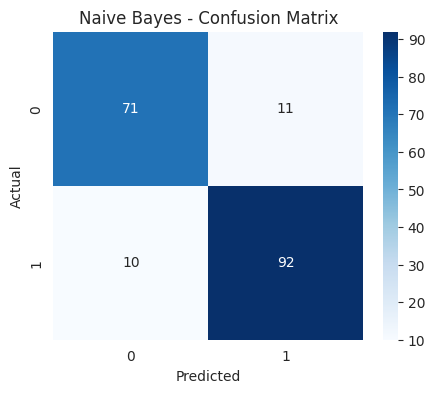

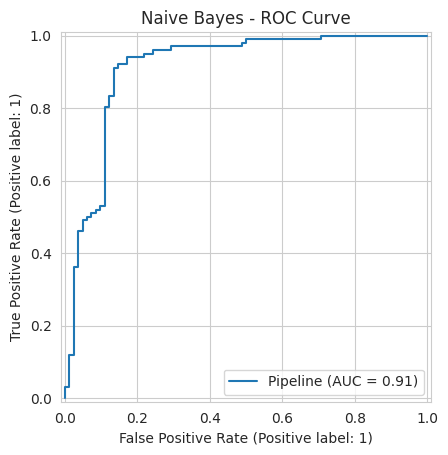

In [30]:
# ==========================================
# NAIVE BAYES - TEST EVALUATION
# ==========================================

best_nb = nb_grid.best_estimator_

nb_results = evaluate_model(
    best_nb,
    X_test,
    y_test,
    model_name="Naive Bayes"
)

results.append(nb_results)

In [31]:
# ==========================================
# NAIVE BAYES INTERPRETATION
# ==========================================

print("Naive Bayes Summary")
print("---------------------")
print("Best parameters:", nb_grid.best_params_)
print(f"Best cross-validation F1 score: {nb_grid.best_score_:.4f}")
print(f"Test F1 score: {nb_results['F1']:.4f}")
print(f"Test AUC score: {nb_results['AUC']:.4f}")

Naive Bayes Summary
---------------------
Best parameters: {'clf__var_smoothing': 1e-09}
Best cross-validation F1 score: 0.8620
Test F1 score: 0.8976
Test AUC score: 0.9118


MODEL PERFORMANCE COMPARISON



,Model,Accuracy,Precision,Recall,F1,AUC
1,Random Forest,0.902174,0.888889,0.941176,0.914286,0.930177
2,Naive Bayes,0.885870,0.893204,0.901961,0.897561,0.911765
0,Decision Tree,0.826087,0.864583,0.813725,0.838384,0.872908


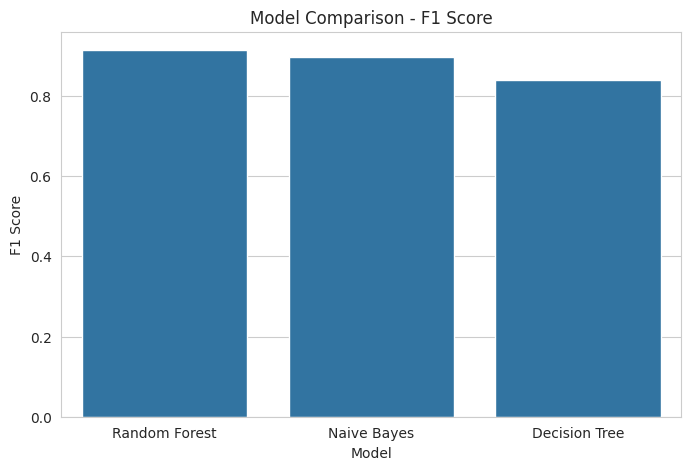

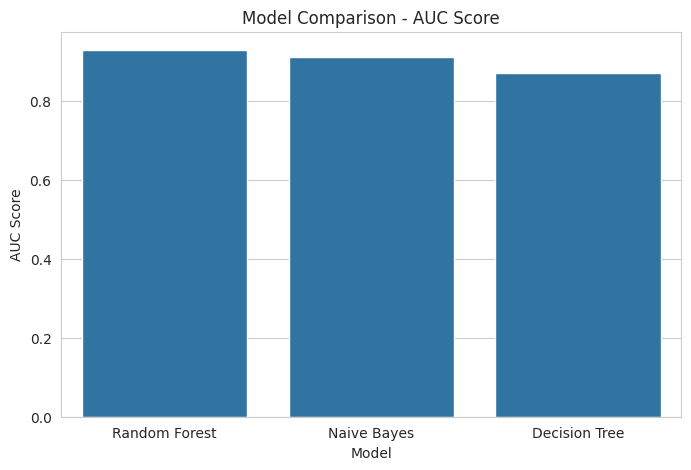


BEST MODEL

Model      : Random Forest
Accuracy   : 0.9022
Precision  : 0.8889
Recall     : 0.9412
F1 Score   : 0.9143
AUC Score  : 0.9302

CONCLUSIONS

1. The Decision Tree classifier achieved an F1 score
   of 0.8384 and an AUC score of 0.8729.

   The model provided good interpretability and
   allowed the identification of the most important
   predictive features for heart disease classification.
   However, its performance was lower compared to
   ensemble-based methods.

2. Random Forest achieved the best overall performance,
   with an F1 score of 0.9143 and an AUC score of 0.9302.

   The ensemble approach significantly improved the
   generalization capability of the model compared
   to a single Decision Tree by reducing overfitting
   and increasing prediction stability.

3. Naive Bayes also achieved strong results,
   with an F1 score of 0.8976 and an AUC score of 0.9118.

   Despite the strong independence assumptions between
   features, the model performed surprisingly

In [33]:
# ==========================================
# RESULTS, COMPARISON AND CONCLUSIONS
# ==========================================

# Results table
results_df = pd.DataFrame(results)

# Sort by F1 score
results_df = results_df.sort_values(
    by='F1',
    ascending=False
)

print("MODEL PERFORMANCE COMPARISON\n")

display(results_df)

# ------------------------------------------
# F1 Score Comparison
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1'
)

plt.title("Model Comparison - F1 Score")
plt.ylabel("F1 Score")

plt.show()

# ------------------------------------------
# AUC Score Comparison
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='AUC'
)

plt.title("Model Comparison - AUC Score")
plt.ylabel("AUC Score")

plt.show()

# ------------------------------------------
# Best Model
# ------------------------------------------

best_model_row = results_df.iloc[0]

print("\nBEST MODEL\n")

print(f"Model      : {best_model_row['Model']}")
print(f"Accuracy   : {best_model_row['Accuracy']:.4f}")
print(f"Precision  : {best_model_row['Precision']:.4f}")
print(f"Recall     : {best_model_row['Recall']:.4f}")
print(f"F1 Score   : {best_model_row['F1']:.4f}")
print(f"AUC Score  : {best_model_row['AUC']:.4f}")

# ==========================================
# CONCLUSIONS
# ==========================================

print("""
CONCLUSIONS

1. The Decision Tree classifier achieved an F1 score
   of 0.8384 and an AUC score of 0.8729.

   The model provided good interpretability and
   allowed the identification of the most important
   predictive features for heart disease classification.
   However, its performance was lower compared to
   ensemble-based methods.

2. Random Forest achieved the best overall performance,
   with an F1 score of 0.9143 and an AUC score of 0.9302.

   The ensemble approach significantly improved the
   generalization capability of the model compared
   to a single Decision Tree by reducing overfitting
   and increasing prediction stability.

3. Naive Bayes also achieved strong results,
   with an F1 score of 0.8976 and an AUC score of 0.9118.

   Despite the strong independence assumptions between
   features, the model performed surprisingly well on
   this dataset while maintaining very fast training time.

4. The results indicate that ensemble methods such as
   Random Forest are more robust and accurate for this
   heart disease classification problem.

5. Feature importance analysis revealed that the most
   influential variables were related to:
   - Chest pain type
   - ST slope
   - Maximum heart rate
   - Oldpeak
   - Exercise-induced angina

6. Overall, Random Forest provided the best balance
   between precision, recall, F1 score and AUC score,
   making it the most suitable model among the tested
   classifiers for this dataset.
""")

In [35]:
results_df

import joblib

joblib.dump(best_dt, "best_models/best_decision_tree.pkl")
joblib.dump(best_rf, "best_models/best_random_forest.pkl")
joblib.dump(best_nb, "best_models/best_naive_bayes.pkl")

['best_naive_bayes.pkl']